In [1]:
# Make src/ importable from the notebook
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import generate_mock_dam_prices, save_prices

%matplotlib inline

In [2]:
# Generate 90 days of mock Greek DAM prices, hourly
start = pd.Timestamp("2024-01-01", tz="Europe/Athens")
end = pd.Timestamp("2024-04-01", tz="Europe/Athens")

prices = generate_mock_dam_prices(start, end)
print(f"Shape: {prices.shape}")
print(f"Range: {prices.index.min()} to {prices.index.max()}")
prices.head()

Shape: (2183,)
Range: 2024-01-01 00:00:00+02:00 to 2024-03-31 23:00:00+03:00


2024-01-01 00:00:00+02:00    73.459962
2024-01-01 01:00:00+02:00    51.680127
2024-01-01 02:00:00+02:00    59.705327
2024-01-01 03:00:00+02:00    61.543756
2024-01-01 04:00:00+02:00    45.858007
Freq: h, Name: price_eur_mwh, dtype: float64

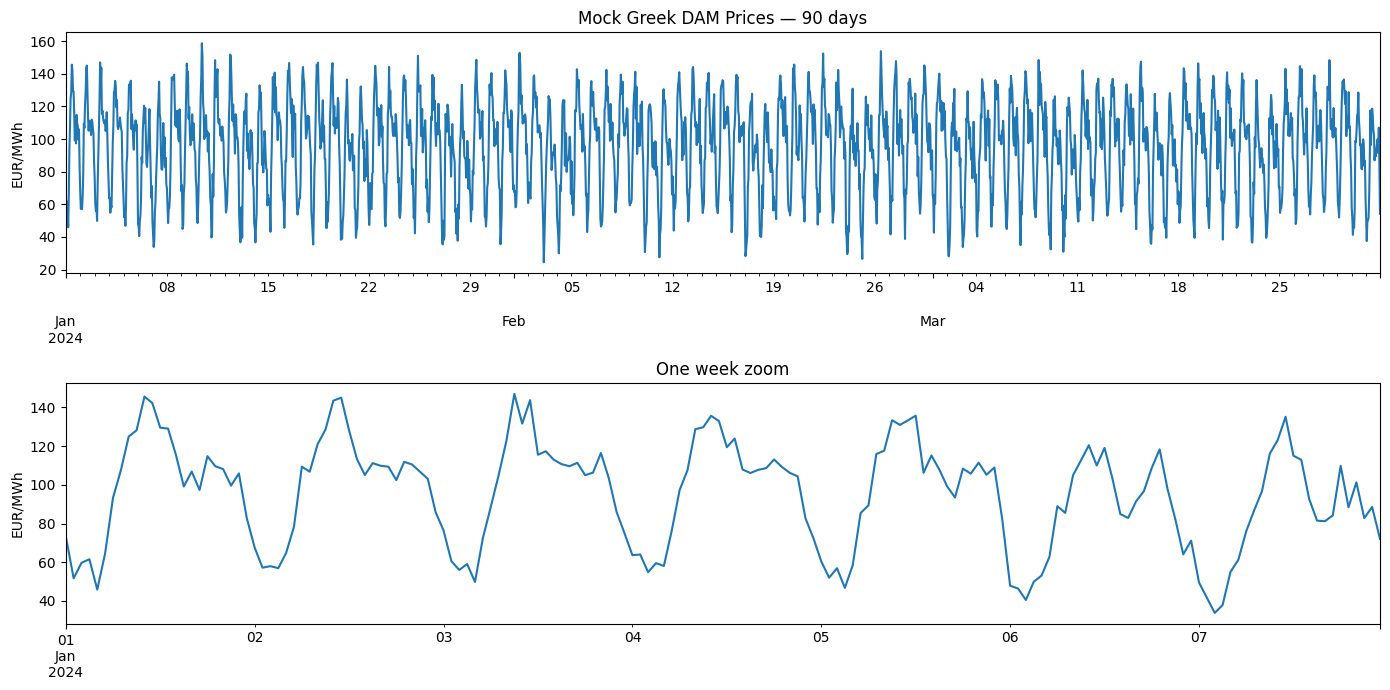

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Full series
prices.plot(ax=axes[0], title="Mock Greek DAM Prices — 90 days")
axes[0].set_ylabel("EUR/MWh")

# Zoom: one week, see daily/weekly patterns
prices.loc["2024-01-01":"2024-01-07"].plot(ax=axes[1], title="One week zoom")
axes[1].set_ylabel("EUR/MWh")

plt.tight_layout()
plt.show()

In [4]:
save_prices(prices, "../data/raw/mock_dam_prices_gr.csv")
print("Saved.")

Saved.
